# Geo-FNO Least-Squares Projection Diagnostic

This notebook tests the representational part of Geo-FNO directly.

Instead of using the current `fft2d/ifft2d` implementation as a roundtrip, it builds the truncated Fourier basis on the irregular sample points and solves the best-fit coefficients by least squares:

$$c^* = \arg\min_c \|\Phi c - u\|_2$$

Then it reconstructs the field with the same retained modes:

$$\hat u = \Phi c^*$$

This is the proper projection question: "How well can this field be represented by the retained Fourier modes on these sample points?"

Interpretation:
- If the **no-IPHI** projection is already bad, the retained spectral space itself is too weak for the field on this geometry/resolution.
- If **no-IPHI** is good but **with-IPHI** is bad, the mapping is making the projected coordinates harder to represent.
- If both projections are good but the trained model is still poor, the main issue is likely optimization/modeling rather than the spectral representation.


In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import torch

from geo_FNO_def import IPHI, get_global_L_from_h5

# ----------------------------
# Config
# ----------------------------
H5_PATH = "/scratch/mnhagen/datasets/incompressible_euler/test.h5"
sample_id = "sample_000034"
t_in = 0
field_type = "ux"   # "ux", "uy", or "speed"

# Must match the trained run you want to diagnose.
modes1 = 24
modes2 = 12

# Optional mapped projection using a trained IPHI.
USE_IPHI = True
IPHI_CKPT = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_asymmetrical_iphi.pt"

boundary_label = 6
band_frac = 0.06
num_x_bins = 40

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda:0


In [2]:
# ----------------------------
# Utilities
# ----------------------------
def fit_circle_kasa(x: np.ndarray, y: np.ndarray):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a * a + b_ * b_) / 4.0 - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(xc), float(yc), float(r)


def estimate_cylinder_from_label6(pos: np.ndarray, node_type: np.ndarray,
                                  boundary_label: int = 6, band_frac: float = 0.06):
    xy = pos[node_type == boundary_label]
    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    cyl_mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[cyl_mask]
    xc, yc, r = fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])
    return xc, yc, r


def retained_wavenumbers(modes1: int, modes2: int):
    k1 = np.concatenate([
        np.arange(0, modes1, dtype=np.int64),
        np.arange(-modes1, 0, dtype=np.int64),
    ])
    k2 = np.concatenate([
        np.arange(0, modes2, dtype=np.int64),
        np.arange(-(modes2 - 1), 0, dtype=np.int64),
    ])
    return k1, k2


def build_basis(x: np.ndarray, modes1: int, modes2: int, L):
    """
    Complex Fourier basis evaluated at arbitrary points x:(N,2).
    Basis size is N x (2*modes1)*(2*modes2-1), matching retained Geo-FNO modes.
    """
    k1, k2 = retained_wavenumbers(modes1, modes2)
    K1, K2 = np.meshgrid(k1, k2, indexing="ij")
    phase = (x[:, 0:1, None] * K1[None, :, :] / float(L[0]) +
             x[:, 1:2, None] * K2[None, :, :] / float(L[1]))
    Phi = np.exp(1j * 2.0 * np.pi * phase)
    return Phi.reshape(x.shape[0], -1)


def project_least_squares(field: np.ndarray, x_proj: np.ndarray, modes1: int, modes2: int, L):
    """
    Solve the best-fit Fourier coefficients on the irregular points and reconstruct.
    Returns reconstruction, coefficients, basis, and singular values.
    """
    Phi = build_basis(x_proj, modes1, modes2, L)
    coeff, residuals, rank, svals = np.linalg.lstsq(Phi, field.astype(np.complex128), rcond=None)
    recon = (Phi @ coeff).real.astype(np.float32)
    info = {
        "residuals": residuals,
        "rank": int(rank),
        "svals": svals,
        "condition_est": float(svals[0] / svals[-1]) if len(svals) > 0 and svals[-1] > 0 else np.inf,
        "num_basis": int(Phi.shape[1]),
        "num_points": int(Phi.shape[0]),
    }
    return recon, coeff, Phi, info


def rel_rmse(pred: np.ndarray, target: np.ndarray, eps: float = 1e-12):
    return float(np.sqrt(np.mean((pred - target) ** 2) / max(np.mean(target ** 2), eps)))


def x_binned_abs_error(xcoord: np.ndarray, diff: np.ndarray, num_bins: int):
    edges = np.linspace(float(xcoord.min()), float(xcoord.max()), num_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    vals = np.full(num_bins, np.nan, dtype=np.float64)
    adiff = np.abs(diff)
    for i in range(num_bins):
        if i == num_bins - 1:
            mask = (xcoord >= edges[i]) & (xcoord <= edges[i + 1])
        else:
            mask = (xcoord >= edges[i]) & (xcoord < edges[i + 1])
        if np.any(mask):
            vals[i] = float(adiff[mask].mean())
    return centers, vals


def left_right_mae(xcoord: np.ndarray, diff: np.ndarray):
    xmid = 0.5 * (float(xcoord.min()) + float(xcoord.max()))
    adiff = np.abs(diff)
    left = float(adiff[xcoord <= xmid].mean())
    right = float(adiff[xcoord > xmid].mean())
    return left, right, float(right / max(left, 1e-12))


In [3]:
# ----------------------------
# Load sample and optional IPHI
# ----------------------------
with h5py.File(H5_PATH, "r") as f:
    g = f[sample_id]
    pos = g["pos"][:]
    cells = g["cells"][:]
    node_type = g["node_type"][:]
    vel = g["vel"][:]

u0 = vel[t_in].astype(np.float32)
if field_type == "ux":
    field = u0[:, 0]
elif field_type == "uy":
    field = u0[:, 1]
elif field_type == "speed":
    field = np.linalg.norm(u0, axis=1)
else:
    raise ValueError(f"Unsupported field_type={field_type}")

triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells)
L_global, key_used = get_global_L_from_h5(H5_PATH)
print("Using L_global from", key_used, ":", L_global)
print("sample:", sample_id, "field:", field_type)

xc, yc, r = estimate_cylinder_from_label6(pos, node_type, boundary_label=boundary_label, band_frac=band_frac)
code42 = np.zeros((42,), dtype=np.float32)
code42[0], code42[1], code42[2] = xc, yc, r

mapped_pos = None
if USE_IPHI and os.path.exists(IPHI_CKPT):
    iphi = IPHI(width=32, device=str(device)).to(device)
    iphi.load_state_dict(torch.load(IPHI_CKPT, map_location=device), strict=False)
    iphi.eval()
    with torch.no_grad():
        mapped_pos = iphi(
            torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device),
            torch.from_numpy(code42).unsqueeze(0).to(device),
        )[0].cpu().numpy().astype(np.float64)
    print("Loaded IPHI checkpoint:", IPHI_CKPT)
elif USE_IPHI:
    print("IPHI checkpoint not found; running only no-IPHI projection.")


Using L_global from sample_000000 : [1.600000023841858, 0.4099999964237213]
sample: sample_000034 field: ux
Loaded IPHI checkpoint: /scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_asymmetrical_iphi.pt


In [4]:
# ----------------------------
# Proper projection: least-squares in retained Fourier basis
# ----------------------------
recon_nomap, coeff_nomap, Phi_nomap, info_nomap = project_least_squares(
    field=field,
    x_proj=pos.astype(np.float64),
    modes1=modes1,
    modes2=modes2,
    L=L_global,
)

diff_nomap = field - recon_nomap
rel_nomap = rel_rmse(recon_nomap, field)
left_nomap, right_nomap, ratio_nomap = left_right_mae(pos[:, 0], diff_nomap)
centers_nomap, binned_nomap = x_binned_abs_error(pos[:, 0], diff_nomap, num_x_bins)

print("No-IPHI projection")
print(f"  relRMSE      : {rel_nomap:.6e}")
print(f"  rank         : {info_nomap['rank']} / {info_nomap['num_basis']}")
print(f"  cond estimate: {info_nomap['condition_est']:.3e}")
print(f"  left/right MAE: {left_nomap:.3e} / {right_nomap:.3e}  (right/left={ratio_nomap:.3f})")

recon_iphi = None
diff_iphi = None
rel_iphi = None
ratio_iphi = None
centers_iphi = None
binned_iphi = None

if mapped_pos is not None:
    recon_iphi, coeff_iphi, Phi_iphi, info_iphi = project_least_squares(
        field=field,
        x_proj=mapped_pos,
        modes1=modes1,
        modes2=modes2,
        L=L_global,
    )
    diff_iphi = field - recon_iphi
    rel_iphi = rel_rmse(recon_iphi, field)
    left_iphi, right_iphi, ratio_iphi = left_right_mae(pos[:, 0], diff_iphi)
    centers_iphi, binned_iphi = x_binned_abs_error(pos[:, 0], diff_iphi, num_x_bins)

    print("With-IPHI projection")
    print(f"  relRMSE      : {rel_iphi:.6e}")
    print(f"  rank         : {info_iphi['rank']} / {info_iphi['num_basis']}")
    print(f"  cond estimate: {info_iphi['condition_est']:.3e}")
    print(f"  left/right MAE: {left_iphi:.3e} / {right_iphi:.3e}  (right/left={ratio_iphi:.3f})")


No-IPHI projection
  relRMSE      : 1.941635e-01
  rank         : 1104 / 1104
  cond estimate: 8.179e+04
  left/right MAE: 2.690e-02 / 2.453e-02  (right/left=0.912)
With-IPHI projection
  relRMSE      : 1.374640e-01
  rank         : 1104 / 1104
  cond estimate: 4.808e+11
  left/right MAE: 1.599e-02 / 1.892e-02  (right/left=1.183)


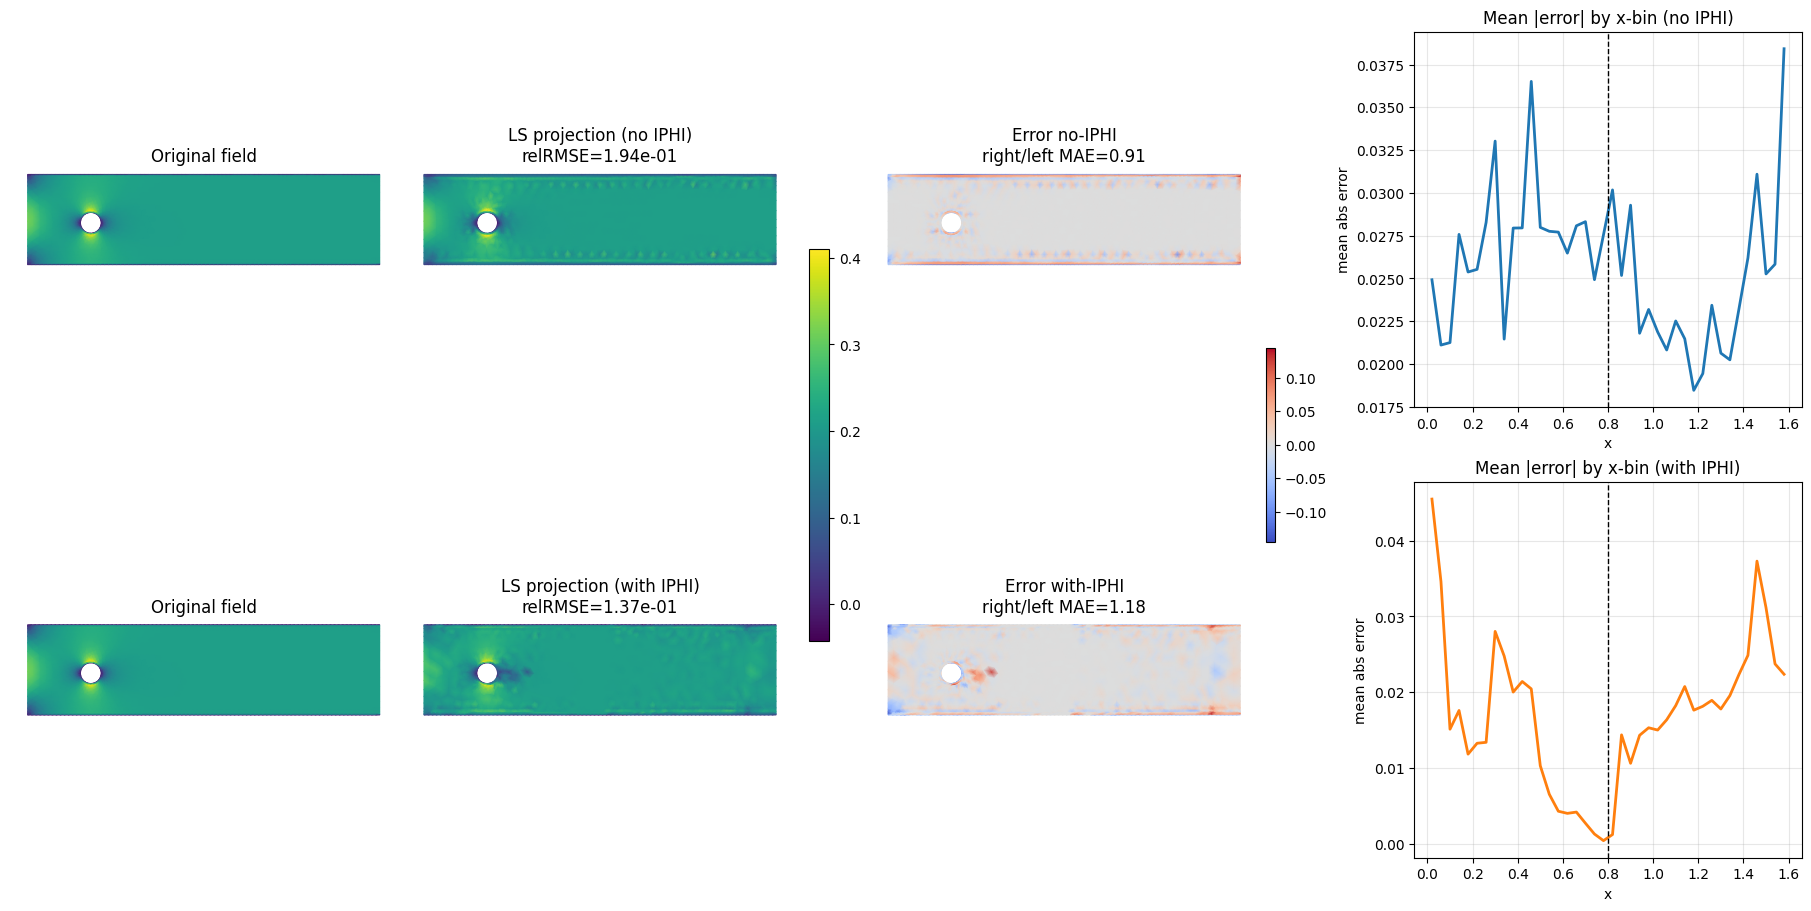

In [5]:
# ----------------------------
# Visualization
# ----------------------------
if recon_iphi is None:
    vmin = float(min(field.min(), recon_nomap.min()))
    vmax = float(max(field.max(), recon_nomap.max()))
    dabs = float(np.max(np.abs(diff_nomap)))

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), constrained_layout=True)

    im0 = axes[0].tripcolor(triang, field, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[0].set_title("Original field")
    axes[0].set_aspect("equal")
    axes[0].axis("off")

    im1 = axes[1].tripcolor(triang, recon_nomap, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"LS projection (no IPHI)\nrelRMSE={rel_nomap:.2e}")
    axes[1].set_aspect("equal")
    axes[1].axis("off")

    im2 = axes[2].tripcolor(triang, diff_nomap, shading="gouraud", cmap="coolwarm", vmin=-dabs, vmax=dabs)
    axes[2].set_title(f"Error: original - projected\nright/left MAE={ratio_nomap:.2f}")
    axes[2].set_aspect("equal")
    axes[2].axis("off")

    axes[3].plot(centers_nomap, binned_nomap, lw=2)
    axes[3].axvline(0.5 * (pos[:, 0].min() + pos[:, 0].max()), color="black", ls="--", lw=1)
    axes[3].set_title("Mean |error| by x-bin")
    axes[3].set_xlabel("x")
    axes[3].set_ylabel("mean abs error")
    axes[3].grid(True, alpha=0.3)

    fig.colorbar(im1, ax=[axes[0], axes[1]], fraction=0.03, pad=0.02)
    fig.colorbar(im2, ax=axes[2], fraction=0.03, pad=0.02)
    plt.show()
else:
    vmin = float(min(field.min(), recon_nomap.min(), recon_iphi.min()))
    vmax = float(max(field.max(), recon_nomap.max(), recon_iphi.max()))
    dabs = float(max(np.max(np.abs(diff_nomap)), np.max(np.abs(diff_iphi))))

    fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)

    im00 = axes[0, 0].tripcolor(triang, field, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[0, 0].set_title("Original field")
    axes[0, 0].set_aspect("equal")
    axes[0, 0].axis("off")

    im01 = axes[0, 1].tripcolor(triang, recon_nomap, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[0, 1].set_title(f"LS projection (no IPHI)\nrelRMSE={rel_nomap:.2e}")
    axes[0, 1].set_aspect("equal")
    axes[0, 1].axis("off")

    im02 = axes[0, 2].tripcolor(triang, diff_nomap, shading="gouraud", cmap="coolwarm", vmin=-dabs, vmax=dabs)
    axes[0, 2].set_title(f"Error no-IPHI\nright/left MAE={ratio_nomap:.2f}")
    axes[0, 2].set_aspect("equal")
    axes[0, 2].axis("off")

    axes[0, 3].plot(centers_nomap, binned_nomap, lw=2)
    axes[0, 3].axvline(0.5 * (pos[:, 0].min() + pos[:, 0].max()), color="black", ls="--", lw=1)
    axes[0, 3].set_title("Mean |error| by x-bin (no IPHI)")
    axes[0, 3].set_xlabel("x")
    axes[0, 3].set_ylabel("mean abs error")
    axes[0, 3].grid(True, alpha=0.3)

    im10 = axes[1, 0].tripcolor(triang, field, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[1, 0].set_title("Original field")
    axes[1, 0].set_aspect("equal")
    axes[1, 0].axis("off")

    im11 = axes[1, 1].tripcolor(triang, recon_iphi, shading="gouraud", vmin=vmin, vmax=vmax)
    axes[1, 1].set_title(f"LS projection (with IPHI)\nrelRMSE={rel_iphi:.2e}")
    axes[1, 1].set_aspect("equal")
    axes[1, 1].axis("off")

    im12 = axes[1, 2].tripcolor(triang, diff_iphi, shading="gouraud", cmap="coolwarm", vmin=-dabs, vmax=dabs)
    axes[1, 2].set_title(f"Error with-IPHI\nright/left MAE={ratio_iphi:.2f}")
    axes[1, 2].set_aspect("equal")
    axes[1, 2].axis("off")

    axes[1, 3].plot(centers_iphi, binned_iphi, lw=2, color="tab:orange")
    axes[1, 3].axvline(0.5 * (pos[:, 0].min() + pos[:, 0].max()), color="black", ls="--", lw=1)
    axes[1, 3].set_title("Mean |error| by x-bin (with IPHI)")
    axes[1, 3].set_xlabel("x")
    axes[1, 3].set_ylabel("mean abs error")
    axes[1, 3].grid(True, alpha=0.3)

    fig.colorbar(im01, ax=[axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]], fraction=0.025, pad=0.02)
    fig.colorbar(im12, ax=[axes[0, 2], axes[1, 2]], fraction=0.025, pad=0.02)
    plt.show()


## How To Read This

What this projection means:
- The basis matrix `Phi` contains every retained Fourier mode evaluated at the sample points.
- The least-squares solve finds the coefficients that best reproduce the field on those points.
- This is the cleanest answer to: "Given these modes, can the field be represented at all?"

How this differs from the earlier roundtrip:
- The earlier `fft2d/ifft2d` roundtrip on irregular points is not a true inverse pair.
- Here, reconstruction error is not coming from an ad hoc forward/inverse implementation mismatch.
- Error here is mostly about the retained spectral space, the sampling geometry, and the mapping.

How to interpret the outputs:
- `relRMSE`: overall projection error. Small means the field fits the retained basis well.
- `rank`: if this is much smaller than the number of basis functions, the basis is numerically redundant on your points.
- `cond estimate`: large values mean the projection problem is ill-conditioned; tiny perturbations can create large coefficient changes.
- `right/left MAE`: if this is much larger than `1`, the projection error is disproportionately concentrated on the right half.
- `mean |error| by x-bin`: this is the clearest plot for locating seams or a breakdown around a specific x-value like `x \approx 0.8`.

Decision rules:
- If no-IPHI is already bad: increase representational strength first (`modes1`, `modes2`) or reconsider the spectral approach for this dataset.
- If no-IPHI is fine but with-IPHI gets worse or shows a seam: focus on IPHI/mapping regularity and coordinate preprocessing.
- If both are good but training is still poor: the bottleneck is downstream learning, not the projection itself.
